# Diabetes Disease Progression Prediction (Scikit-Learn Diabetes Dataset)

**Goal:** Predict **diabetes disease progression** (numeric target) **one year after baseline**.  
This can support a **screening-style tool** to help physicians identify patients at risk and prioritize follow-up.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make pandas outputs easier to read
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


# Part 1 — Data + EDA

We will:
1. Load the dataset using `datasets.load_diabetes(as_frame=True)`
2. Print and summarize `diabetes.DESCR`
3. Basic dataset summary (shape, columns, target stats)
4. EDA plots + correlation analysis
5. Data checks (missing/duplicates/weird values)
6. Split into Train (75%), Validation (10%), Test (15) with reproducible splits


In [2]:
diabetes = datasets.load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print("=== diabetes.DESCR ===")
print(diabetes.DESCR)


=== diabetes.DESCR ===
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 fea

## Summary of `diabetes.DESCR` (quick)
- This is a **tabular medical dataset** (features already standardized/normalized).
- The target is a **quantitative measure of disease progression** **one year after baseline**.
- Features include variables like **BMI**, blood pressure, and serum measurements (in standardized form).


In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(list(X.columns))

print("\nTarget (y) descriptive stats:")
display(y.describe())

print("\nFirst 5 rows:")
display(pd.concat([X, y.rename("target")], axis=1).head())


X shape: (442, 10)
y shape: (442,)

Columns:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target (y) descriptive stats:


count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 2) Frame the Problem

### What are we predicting?
- **Target:** “disease progression one year after baseline” (numeric value)
- Higher values indicate **worse progression** (more severe outcome proxy).

### Why is this Regression?
- Because the model outputs a **continuous numeric prediction**, not categories.

### Workshop talking points (useful context)
**Performance metrics**
- No single metric tells the full story:
  - **R²** tells how much variance we explain.
  - **MAE** tells average absolute error in target units.
  - **MAPE** gives % error (easy to interpret but can behave badly near zero).
- Using multiple metrics helps detect tradeoffs (e.g., good R² but high MAE at extremes).

**kNN intuition**
- kNN is **distance-based**: predicts using nearby points.
- It **needs scaling**, or features with larger magnitude dominate distance.
- Sensitive to **noise/outliers** because neighbors can be misleading.

**Logistic Regression (Classifier)**
- Logistic Regression is for **classification**, not numeric regression.
- It outputs **probabilities**, then we choose a threshold (e.g., 0.5) to label “high risk”.
- Useful for screening: threshold controls **false positives vs false negatives**.


# 3) Exploratory Data Analysis (EDA)

We will include:
- Descriptive statistics
- Histograms (key features + target)
- Scatter plot: **BMI vs target**
- Correlation matrix heatmap (including target correlations)
- Concise insights


In [4]:
desc = X.describe().T
desc["missing_count"] = X.isna().sum()
display(desc)

print("Target stats:")
display(y.describe())


,count,mean,std,min,25%,50%,75%,max,missing_count
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727,0
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680,0
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555,0
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044,0
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914,0
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788,0
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179,0
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234,0
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597,0
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612,0


Target stats:


count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

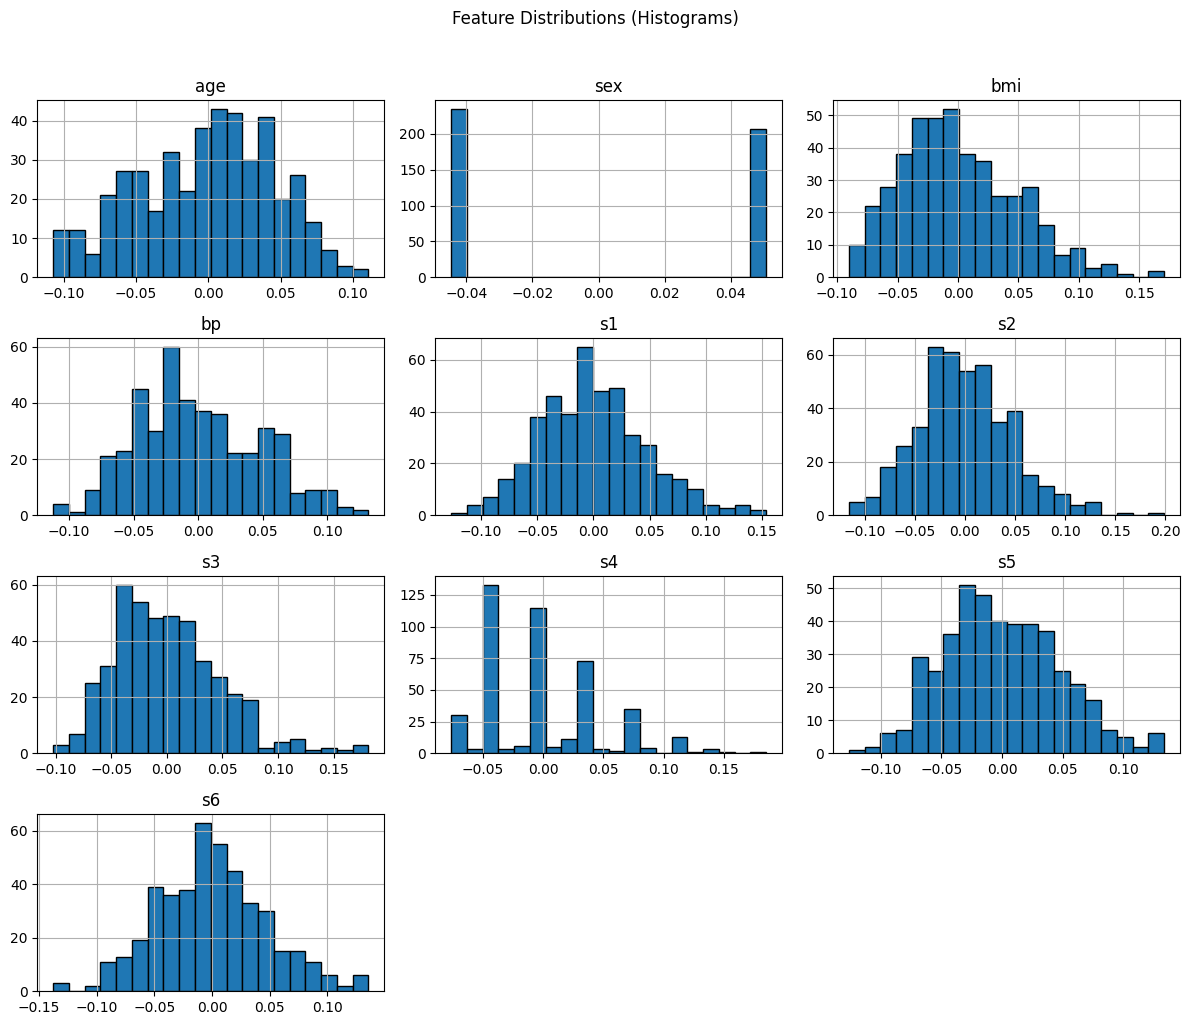

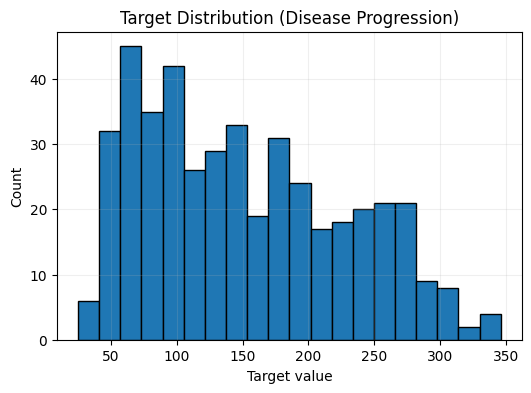

In [5]:
# Histograms for all features
ax = X.hist(bins=20, figsize=(12, 10), edgecolor="black")
plt.suptitle("Feature Distributions (Histograms)", y=1.02)
plt.tight_layout()
plt.show()

# Target histogram
plt.figure(figsize=(6,4))
plt.hist(y, bins=20, edgecolor="black")
plt.title("Target Distribution (Disease Progression)")
plt.xlabel("Target value")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.show()


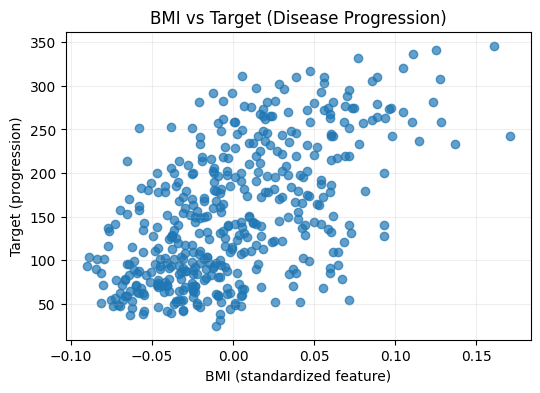

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(X["bmi"], y, alpha=0.7)
plt.title("BMI vs Target (Disease Progression)")
plt.xlabel("BMI (standardized feature)")
plt.ylabel("Target (progression)")
plt.grid(alpha=0.2)
plt.show()


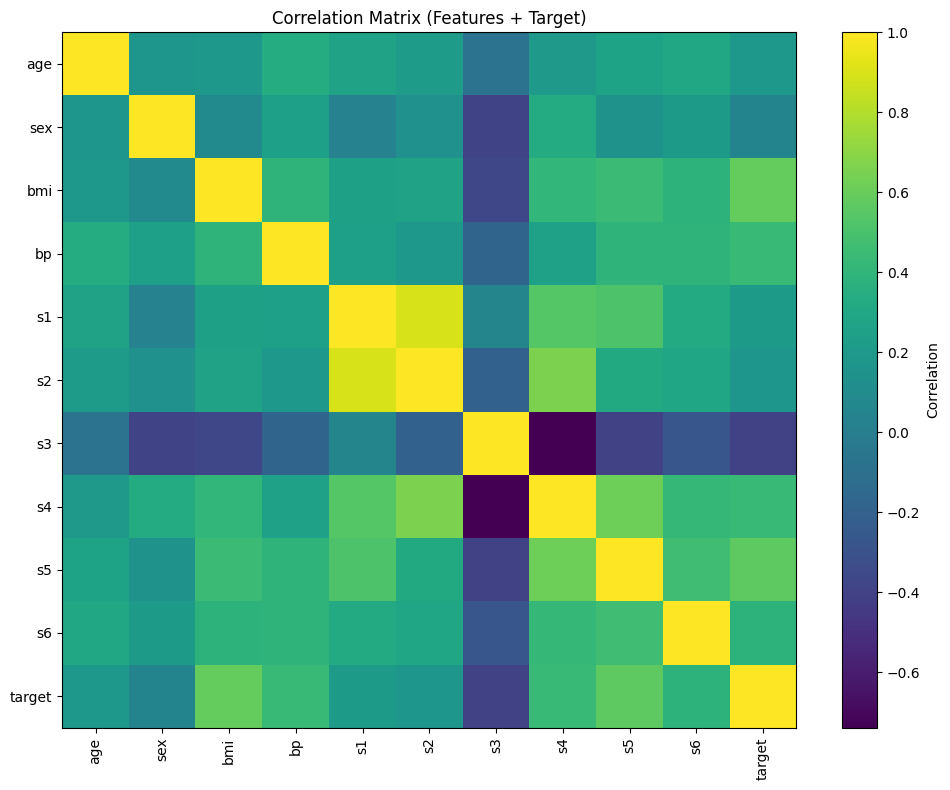

Correlation with target (sorted):


,corr_with_target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062
s3,-0.394789


In [7]:
df_all = X.copy()
df_all["target"] = y

corr = df_all.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix (Features + Target)")

ticks = np.arange(len(corr.columns))
plt.xticks(ticks, corr.columns, rotation=90)
plt.yticks(ticks, corr.columns)

plt.tight_layout()
plt.show()

# Show target correlations sorted
target_corr = corr["target"].drop("target").sort_values(ascending=False)
print("Correlation with target (sorted):")
display(target_corr.to_frame("corr_with_target"))


## EDA Insights (concise)
- **BMI often shows one of the stronger positive relationships** with progression (visible in scatter + correlation).
- Some serum-related features may correlate positively or negatively, but many correlations are **moderate**, not extreme.
- Correlation does not prove causation, but it helps guide feature use:
  - Weak correlations suggest single-variable models may underfit.
  - Multiple features can improve prediction by capturing different physiological signals.


# 4) Cleaning / Data Quality Checks

We check:
- Missing values
- Duplicate rows
- “Weird values” (extreme outliers/ranges)

If nothing is found, we clearly state: **no cleaning needed** (and why).


In [8]:
# Missing values
missing_X = X.isna().sum().sum()
missing_y = y.isna().sum()
print("Total missing in X:", missing_X)
print("Total missing in y:", missing_y)

# Duplicates (check full row duplicates including target)
full_df = pd.concat([X, y.rename("target")], axis=1)
dup_count = full_df.duplicated().sum()
print("Duplicate rows (X + y):", dup_count)

# Quick range check (features are standardized; extremes can exist but should be finite)
finite_ok = np.isfinite(X.to_numpy()).all() and np.isfinite(y.to_numpy()).all()
print("All values finite (no inf/nan)?", finite_ok)

display(X.agg(["min", "max"]).T)


Total missing in X: 0
Total missing in y: 0
Duplicate rows (X + y): 0
All values finite (no inf/nan)? True


,min,max
age,-0.107226,0.110727
sex,-0.044642,0.050680
bmi,-0.090275,0.170555
bp,-0.112399,0.132044
s1,-0.126781,0.153914
s2,-0.115613,0.198788
s3,-0.102307,0.181179
s4,-0.076395,0.185234
s5,-0.126097,0.133597
s6,-0.137767,0.135612


## Cleaning conclusion
- If missing values = 0 and duplicates = 0 and all values are finite, then:
  - **No cleaning needed** because the dataset is already standardized, complete, and consistent.
- We still remain cautious about **outliers**, since standardized medical data can include extremes that affect models (especially kNN and high-degree polynomials).


# 5) Split Data (Avoid Leakage)

We split into:
- **Train: 75%**
- **Validation: 10%**
- **Test: 15%**

We do it as:
1) Train vs Temp (25%)  
2) Temp → Validation (40% of temp) and Test (60% of temp)

This ensures: 0.75 / 0.10 / 0.15 exactly.


In [9]:
# 1) Train vs temp (25%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, shuffle=True
)

# 2) Temp -> val/test with 40/60 split of temp => 10% / 15% overall
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.60, random_state=RANDOM_STATE, shuffle=True
)

print("Sizes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# Confirm no overlap by checking index uniqueness
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print("\nOverlap checks (should be 0):")
print("Train ∩ Val:", len(train_idx.intersection(val_idx)))
print("Train ∩ Test:", len(train_idx.intersection(test_idx)))
print("Val ∩ Test:", len(val_idx.intersection(test_idx)))


Sizes:
Train: (331, 10) (331,)
Val:   (44, 10) (44,)
Test:  (67, 10) (67,)

Overlap checks (should be 0):
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


# Metrics (Regression)

We compute for **train/val/test**:
- **R²**: “how much variance explained”
- **MAE**: average absolute error (same units as target)
- **MAPE**: average percent error (interpretable, but tricky when y is near 0)


In [10]:
def safe_mape(y_true, y_pred, eps=1e-8):
    """
    MAPE = mean(|(y - yhat) / y|) * 100
    Safe handling: avoid division by tiny values using eps.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < eps, eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def regression_report(model, X_tr, y_tr, X_va, y_va, X_te=None, y_te=None):
    """Returns metrics on train/val/(optional test)."""
    out = {}

    pred_tr = model.predict(X_tr)
    out["train_r2"] = r2_score(y_tr, pred_tr)
    out["train_mae"] = mean_absolute_error(y_tr, pred_tr)
    out["train_mape"] = safe_mape(y_tr, pred_tr)

    pred_va = model.predict(X_va)
    out["val_r2"] = r2_score(y_va, pred_va)
    out["val_mae"] = mean_absolute_error(y_va, pred_va)
    out["val_mape"] = safe_mape(y_va, pred_va)

    if X_te is not None and y_te is not None:
        pred_te = model.predict(X_te)
        out["test_r2"] = r2_score(y_te, pred_te)
        out["test_mae"] = mean_absolute_error(y_te, pred_te)
        out["test_mape"] = safe_mape(y_te, pred_te)

    return out


# Part 2 — Univariate Polynomial Regression (BMI only)

We build **6 models** using ONLY BMI:
- Degrees **0, 1, 2, 3, 4, 5**

Model form:
- Degree 0 = constant predictor (intercept-only)  
- Degree d ≥ 1 = `PolynomialFeatures(degree=d, include_bias=False) + LinearRegression()`

We evaluate on **Train + Validation**, select best on validation, then test.


In [11]:
X_train_bmi = X_train[["bmi"]]
X_val_bmi   = X_val[["bmi"]]
X_test_bmi  = X_test[["bmi"]]


In [12]:
results_bmi = []

for d in range(0, 6):
    if d == 0:
        # Degree 0 => intercept-only model (mean predictor)
        model = DummyRegressor(strategy="mean")
    else:
        model = Pipeline(steps=[
            ("poly", PolynomialFeatures(degree=d, include_bias=False)),
            ("linreg", LinearRegression())
        ])
    
    model.fit(X_train_bmi, y_train)
    rep = regression_report(model, X_train_bmi, y_train, X_val_bmi, y_val)
    rep["degree"] = d
    results_bmi.append(rep)

bmi_table = pd.DataFrame(results_bmi).set_index("degree").sort_index()
display(bmi_table)


,train_r2,train_mae,train_mape,val_r2,val_mae,val_mape
degree,,,,,,
0,0.000000,66.201641,62.826669,-0.106957,66.057059,71.263880
1,0.349672,52.287739,48.362886,0.331264,47.208472,47.060009
2,0.350764,52.207314,48.298534,0.331631,47.213700,47.239667
3,0.350774,52.198968,48.280744,0.331638,47.185414,47.222673
4,0.353014,52.092653,48.053266,0.340758,46.090118,46.050330
5,0.354100,52.059191,48.004022,0.349881,45.462121,45.175275


## 8) Choosing the best model
We select the degree that performs best on **validation** (primary), using:
- Higher **Validation R²** is better
- Lower **Validation MAE/MAPE** is better  
If metrics disagree, we prefer the model that generalizes better (not overly complex).


In [13]:
# Rule: maximize val_r2, tie-break by minimizing val_mae
best_degree = (
    bmi_table
    .sort_values(["val_r2", "val_mae"], ascending=[False, True])
    .index[0]
)

best_degree


5

In [14]:
# Refit chosen model on train+val (still no test leakage)
X_trainval_bmi = pd.concat([X_train_bmi, X_val_bmi], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

if best_degree == 0:
    best_bmi_model = DummyRegressor(strategy="mean")
else:
    best_bmi_model = Pipeline(steps=[
        ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])

best_bmi_model.fit(X_trainval_bmi, y_trainval)

# Final test report
test_rep_bmi = regression_report(best_bmi_model, X_train_bmi, y_train, X_val_bmi, y_val, X_test_bmi, y_test)
test_rep_bmi


{'train_r2': 0.3538258597239079,
 'train_mae': 52.05994042987637,
 'train_mape': np.float64(47.71182016705814),
 'val_r2': 0.35519760869955885,
 'val_mae': 44.99671147585975,
 'val_mape': np.float64(44.33476699980783),
 'test_r2': 0.26680066547464154,
 'test_mae': 51.680783429708356,
 'test_mape': np.float64(42.70287242951881)}

## 9) Chosen BMI-only model performance (Test set)
We report **R², MAE, MAPE** on the test set as our final unbiased estimate for the selected degree.


In [15]:
summary_bmi = pd.DataFrame([{
    "best_degree": best_degree,
    "test_r2": test_rep_bmi["test_r2"],
    "test_mae": test_rep_bmi["test_mae"],
    "test_mape": test_rep_bmi["test_mape"]
}])
display(summary_bmi)


,best_degree,test_r2,test_mae,test_mape
0,5,0.266801,51.680783,42.702872


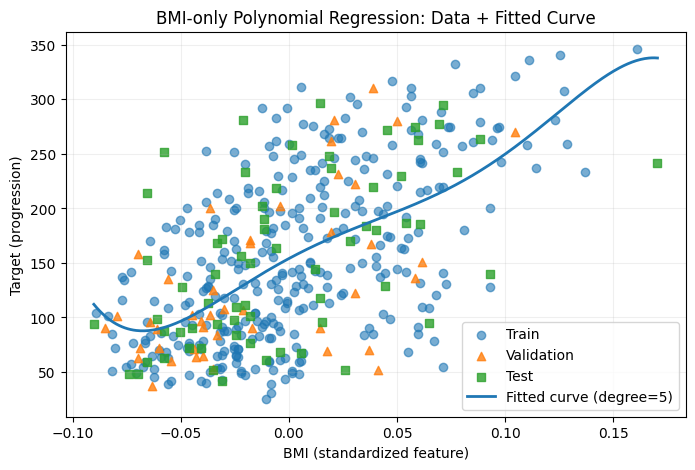

In [16]:
# Scatter points
plt.figure(figsize=(8,5))
plt.scatter(X_train_bmi["bmi"], y_train, alpha=0.6, label="Train", marker="o")
plt.scatter(X_val_bmi["bmi"], y_val, alpha=0.8, label="Validation", marker="^")
plt.scatter(X_test_bmi["bmi"], y_test, alpha=0.8, label="Test", marker="s")

# Smooth curve over BMI range
bmi_min = X["bmi"].min()
bmi_max = X["bmi"].max()
bmi_grid = np.linspace(bmi_min, bmi_max, 400).reshape(-1, 1)
bmi_grid_df = pd.DataFrame(bmi_grid, columns=["bmi"])
y_curve = best_bmi_model.predict(bmi_grid_df)

plt.plot(bmi_grid, y_curve, linewidth=2, label=f"Fitted curve (degree={best_degree})")

plt.title("BMI-only Polynomial Regression: Data + Fitted Curve")
plt.xlabel("BMI (standardized feature)")
plt.ylabel("Target (progression)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# 11) Equation of the best BMI model

We write:
\[
y = b_0 + b_1 x + b_2 x^2 + \dots
\]
Coefficients will be rounded to **2 decimals**.


In [17]:
def bmi_model_equation(model, degree):
    if degree == 0:
        b0 = float(model.constant_) if hasattr(model, "constant_") else float(model.predict([[0]]))
        return f"y = {b0:.2f}"
    
    poly = model.named_steps["poly"]
    lin = model.named_steps["linreg"]
    
    feature_names = poly.get_feature_names_out(["bmi"])
    coefs = lin.coef_
    intercept = lin.intercept_
    
    terms = [f"{intercept:.2f}"]
    for name, c in zip(feature_names, coefs):
        terms.append(f"({c:.2f})*{name}")
    
    return "y = " + " + ".join(terms)

eq_str = bmi_model_equation(best_bmi_model, best_degree)
eq_str


'y = 154.02 + (1060.83)*bmi + (-5243.18)*bmi^2 + (-12227.11)*bmi^3 + (950057.50)*bmi^4 + (-4072540.60)*bmi^5'

# 12) Predict progression for a sample BMI
We’ll choose a BMI value from the dataset range (e.g., median BMI) and predict disease progression.


In [18]:
bmi_sample = float(np.median(X["bmi"]))
bmi_sample_df = pd.DataFrame({"bmi": [bmi_sample]})

pred_sample = best_bmi_model.predict(bmi_sample_df)[0]

print("Sample BMI (standardized):", bmi_sample)
print("Predicted progression:", pred_sample)


Sample BMI (standardized): -0.007283766209687899
Predicted progression: 146.02610732150413


# 13) Trainable Parameters vs Degree

For a **univariate polynomial** of degree **d**, parameters = **d + 1** (including intercept).

As degree increases:
- feature count grows (x, x², x³, …)
- model becomes more flexible
- risk of **overfitting** increases (especially with limited data)


In [19]:
if best_degree == 0:
    print("Degree 0 => intercept-only model")
    print("Trainable parameters:", 1)
else:
    poly = best_bmi_model.named_steps["poly"]
    feature_names = poly.get_feature_names_out(["bmi"])
    print("Polynomial features:", feature_names)
    print("Number of polynomial features:", len(feature_names))
    print("Trainable parameters = features + intercept =", len(feature_names) + 1)


Polynomial features: ['bmi' 'bmi^2' 'bmi^3' 'bmi^4' 'bmi^5']
Number of polynomial features: 5
Trainable parameters = features + intercept = 6


# 14) Part 2 Conclusion (BMI-only)

- The best BMI-only degree was selected using **validation performance** to reduce overfitting.
- Typical failure modes:
  - **Underfitting** at low degree: curve too simple.
  - **Overfitting** at high degree: curve bends too much to match train noise, worsening validation/test performance.
  - Extremes: polynomial may **over/underestimate** at the ends of BMI range.

Workshop tie-ins:
- Metric tradeoffs: **R² vs MAE vs MAPE** can disagree.
- kNN vs polynomial: kNN is **local** (neighbors), polynomial is **global** (one curve).
- Logistic regression idea: convert numeric progression into “high risk” classification for screening (thresholds control false positives/negatives).


# Part 3 — Multivariate Models (Using Multiple Features)

We will use **all features** because:
- EDA suggests multiple features have meaningful (even if moderate) relationships with the target.
- Combining features usually improves regression performance vs a single-variable model.

We compare:
A) Polynomial Regression (degrees > 1): **2 and 3**  
B) Decision Trees: **max_depth = 3 and 6**  
C) kNN Regressor: **k = 3 and 15** + scaling  
D) Logistic Regression (classification): create a “high risk” label using **75th percentile of y_train** (screening focus)


In [20]:
reg_models = {
    "Poly2 (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linreg", LinearRegression())
    ]),
    "Poly3 (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("linreg", LinearRegression())
    ]),
    "Tree depth=3": DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Tree depth=6": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "kNN k=3 (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=3))
    ]),
    "kNN k=15 (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=15))
    ]),
}


In [21]:
reg_rows = []

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    rep = regression_report(model, X_train, y_train, X_val, y_val)
    rep["model"] = name
    reg_rows.append(rep)

reg_table = pd.DataFrame(reg_rows).set_index("model").sort_values("val_r2", ascending=False)
display(reg_table)


,train_r2,train_mae,train_mape,val_r2,val_mae,val_mape
model,,,,,,
Poly2 (scaled),0.604815,39.215776,34.605710,0.426319,41.802033,42.277250
kNN k=15 (scaled),0.490646,44.869486,39.179010,0.366229,44.718182,45.458843
kNN k=3 (scaled),0.624329,37.118832,31.548077,0.280741,43.204545,41.411498
Tree depth=3,0.509503,44.259855,38.866592,0.198306,48.126248,47.672897
Tree depth=6,0.768015,27.090226,24.903839,0.041672,53.123174,50.370046
Poly3 (scaled),0.909838,15.650825,14.357186,-43.279862,241.215317,231.212096


## Pick best regression model (based on validation)
We prioritize:
- High **Validation R²**
- Low **Validation MAE** (often most interpretable in target units)
- MAPE is useful, but can be unstable in other datasets (near-zero targets)

After choosing, we refit on **Train+Val** and report **Test** results.


In [22]:
best_reg_name = (
    reg_table
    .sort_values(["val_r2", "val_mae"], ascending=[False, True])
    .index[0]
)
best_reg_name


'Poly2 (scaled)'

In [23]:
best_reg_model = reg_models[best_reg_name]

# Refit on train+val (no test leakage)
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_reg_model.fit(X_trainval, y_trainval)

test_rep_reg = regression_report(best_reg_model, X_train, y_train, X_val, y_val, X_test, y_test)
test_rep_reg


{'train_r2': 0.5987830935286356,
 'train_mae': 39.41873744038299,
 'train_mape': np.float64(34.66347567993344),
 'val_r2': 0.5619795817428155,
 'val_mae': 35.38339604492294,
 'val_mape': np.float64(35.180696077243326),
 'test_r2': 0.38012689562645463,
 'test_mae': 45.561428873665065,
 'test_mape': np.float64(37.835486023665915)}

In [24]:
final_reg_summary = pd.DataFrame([{
    "best_model": best_reg_name,
    "test_r2": test_rep_reg["test_r2"],
    "test_mae": test_rep_reg["test_mae"],
    "test_mape": test_rep_reg["test_mape"]
}])
display(final_reg_summary)


,best_model,test_r2,test_mae,test_mape
0,Poly2 (scaled),0.380127,45.561429,37.835486


# D) Logistic Regression (Classification for Screening)

Because Logistic Regression is a **classifier**, we create a “high risk” label:

### High risk definition
We choose the **75th percentile of y_train** as threshold:
- `y_class = 1 if y >= q75_train else 0`

Why 75th percentile?
- Screening tools often focus on identifying the **highest-risk subgroup** (top quartile).
- This also makes the positive class “more clinically meaningful” than median split.

### Why not R²/MAE/MAPE here?
Those are **regression metrics** and do not apply to classifiers that output class labels/probabilities.

We evaluate using:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC (uses probability ranking; good overall discrimination metric)


In [25]:
q75 = float(np.quantile(y_train, 0.75))
print("High-risk threshold (q75 of y_train):", q75)

y_train_class = (y_train >= q75).astype(int)
y_val_class   = (y_val >= q75).astype(int)
y_test_class  = (y_test >= q75).astype(int)

print("Positive rate (train):", y_train_class.mean())
print("Positive rate (val):  ", y_val_class.mean())
print("Positive rate (test): ", y_test_class.mean())


High-risk threshold (q75 of y_train): 214.0
Positive rate (train): 0.2537764350453172
Positive rate (val):   0.1590909090909091
Positive rate (test):  0.2835820895522388


In [26]:
def classification_report(model, X_va, y_va, X_te, y_te):
    # Predict labels
    y_va_pred = model.predict(X_va)
    y_te_pred = model.predict(X_te)

    # Probabilities for ROC-AUC (need positive class probs)
    y_va_proba = model.predict_proba(X_va)[:, 1]
    y_te_proba = model.predict_proba(X_te)[:, 1]

    out = {
        "val_accuracy": accuracy_score(y_va, y_va_pred),
        "val_precision": precision_score(y_va, y_va_pred, zero_division=0),
        "val_recall": recall_score(y_va, y_va_pred, zero_division=0),
        "val_f1": f1_score(y_va, y_va_pred, zero_division=0),
        "val_roc_auc": roc_auc_score(y_va, y_va_proba),

        "test_accuracy": accuracy_score(y_te, y_te_pred),
        "test_precision": precision_score(y_te, y_te_pred, zero_division=0),
        "test_recall": recall_score(y_te, y_te_pred, zero_division=0),
        "test_f1": f1_score(y_te, y_te_pred, zero_division=0),
        "test_roc_auc": roc_auc_score(y_te, y_te_proba),
    }
    return out

log_models = {
    "LogReg C=1": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "LogReg C=0.1": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(C=0.1, max_iter=2000, random_state=RANDOM_STATE))
    ])
}

log_rows = []
for name, model in log_models.items():
    model.fit(X_train, y_train_class)
    rep = classification_report(model, X_val, y_val_class, X_test, y_test_class)
    rep["model"] = name
    log_rows.append(rep)

log_table = pd.DataFrame(log_rows).set_index("model")
display(log_table)


,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
model,,,,,,,,,,
LogReg C=1,0.886364,0.75,0.428571,0.545455,0.942085,0.835821,0.9,0.473684,0.62069,0.876096
LogReg C=0.1,0.909091,1.00,0.428571,0.600000,0.945946,0.835821,0.9,0.473684,0.62069,0.867325


## Selecting the best logistic model (screening logic)
In screening, **false negatives** (missing a high-risk patient) can be worse than false positives.

So we prioritize:
- High **Recall** (catch as many high-risk as possible)
- Strong **ROC-AUC** (good discrimination)
- Precision matters too (don’t overwhelm clinicians), but recall usually comes first.


In [27]:
best_log_name = (
    log_table
    .sort_values(["val_recall", "val_roc_auc"], ascending=[False, False])
    .index[0]
)
best_log_name


'LogReg C=0.1'

# Final Conclusion

### What worked best?
- **BMI-only polynomial** can capture a simple relationship, but it’s limited because disease progression depends on more than BMI.
- Multivariate models typically perform better because they combine multiple signals (BMI, blood pressure, serum markers, etc.).
- For screening, a **logistic “high-risk” classifier** can be more actionable than a raw regression number because clinicians can use thresholds and decision rules.

### Metric interpretation (regression)
- **R²:** How much variance we explain (higher is better, but doesn’t tell you absolute error).
- **MAE:** Average absolute error (most interpretable in real-world terms).
- **MAPE:** Percent error (intuitive, but can mislead if targets are near zero in other datasets).

### Screening perspective (classification)
- Logistic regression outputs **probability of high-risk** → choose threshold based on clinical goals.
- Threshold tuning controls:
  - **False negatives** (dangerous in screening)
  - **False positives** (burden on clinics)

# Limitations

- The dataset features are standardized; real clinical deployment would require:
  - Real units, robust preprocessing, monitoring drift, and clinician validation.
- Polynomial models can overfit (especially degree 3+) and behave oddly at extremes.
- kNN can be sensitive to noise/outliers and depends heavily on scaling and local density.
- Decision trees can overfit unless tuned (depth, min samples, pruning).
- “High-risk” definition here is statistical (75th percentile) — clinical thresholds would ideally be evidence-based.
